# Tree-Based Ensemble Models: Decision Tree, Random Forest & Gradient Boosting

Decision trees are intuitive models that split the feature space into regions.
Their weakness is overfitting: a deep tree memorises the training data.
Ensemble methods fix this by combining many trees:

- **Random Forest** — trains many deep trees on random subsets of rows *and* features,
  then averages their votes. Variance drops while bias stays low.
- **Gradient Boosting** — trains shallow trees sequentially, each one correcting the
  errors of its predecessor. Bias drops while variance stays controlled.

This notebook compares all three on the `focus_score` / `rating` classification task.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
)
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit, train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)

from scripts.data_loader import load_and_preprocess_data
from scripts.evaluation_metrics import evaluate_model

Failed to read module file 'C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\mahru\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "C:\Users\mahru\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\importlib\__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~

## Load and Preprocess Data

We use the shared preprocessing script which loads `linearized_session_windows.csv`, drops non-feature columns, scales with `StandardScaler`, and splits 80/20. Note: tree-based models are scale-invariant, so scaling does not affect their predictions but keeps the pipeline consistent with other notebooks.

In [2]:
X_train, X_test, y_train, y_test, scaler = load_and_preprocess_data()

n_features = X_train.shape[1]
print(f"Training set shape:   {X_train.shape}")
print(f"Test set shape:       {X_test.shape}")
print(f"Number of features:   {n_features}")
print(f"\nClass distribution (train):")
print(y_train.value_counts().sort_index())

Training set shape:   (9081, 42)
Test set shape:       (2271, 42)
Number of features:   42

Class distribution (train):
rating
1.0     167
2.0    1352
3.0    5258
4.0    1327
5.0     977
Name: count, dtype: int64


## EDA

Before modelling, get a feel for class balance and which raw features correlate with the target. This motivates why we need `class_weight` handling and reveals which sensor signals might matter most.

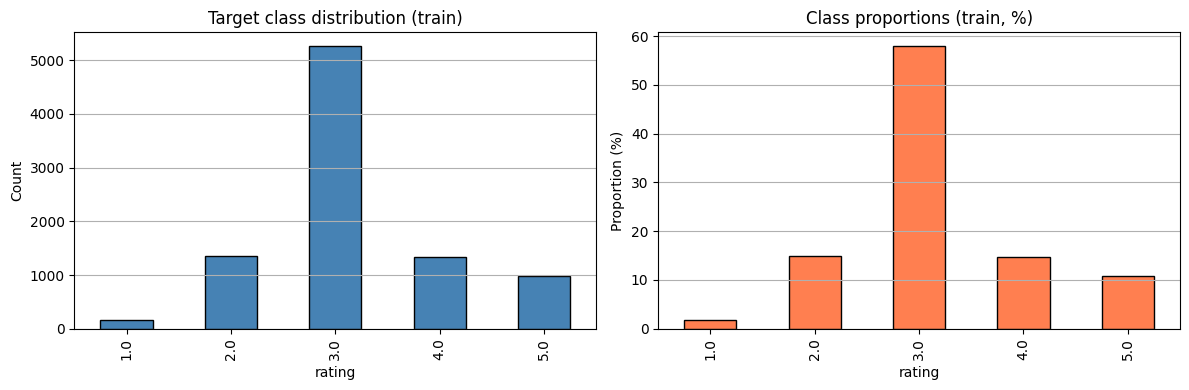

Class proportions:
rating
1.0    0.018
2.0    0.149
3.0    0.579
4.0    0.146
5.0    0.108
Name: proportion, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# class balance
y_train.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="k")
axes[0].set_title("Target class distribution (train)")
axes[0].set_xlabel("rating")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y")

# class proportions
(y_train.value_counts(normalize=True).sort_index() * 100).plot(
    kind="bar", ax=axes[1], color="coral", edgecolor="k"
)
axes[1].set_title("Class proportions (train, %)")
axes[1].set_xlabel("rating")
axes[1].set_ylabel("Proportion (%)")
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

print("Class proportions:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

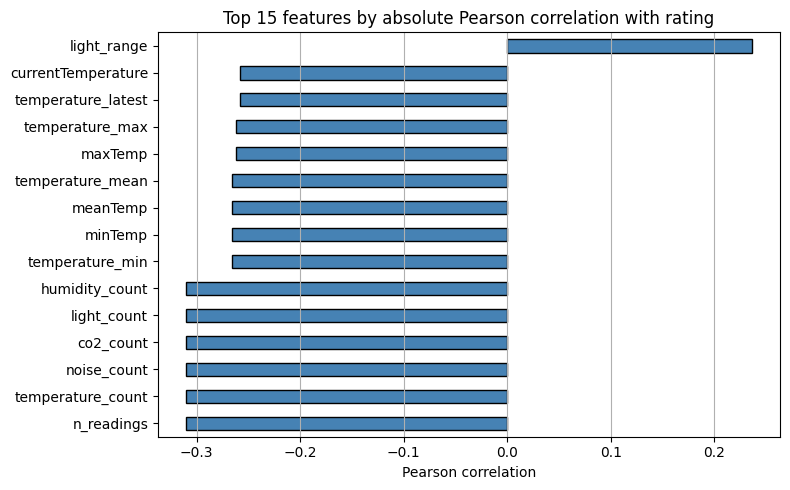

In [4]:
# Quick look: which features have the highest absolute correlation with rating?
# We use the unscaled X from the raw df for interpretability
corr_series = pd.concat([X_train, y_train], axis=1).corr(numeric_only=True)["rating"].drop("rating")
corr_series = corr_series.sort_values(key=lambda x: x.abs(), ascending=False)

plt.figure(figsize=(8, 5))
corr_series.head(15).sort_values().plot(kind="barh", color="steelblue", edgecolor="k")
plt.title("Top 15 features by absolute Pearson correlation with rating")
plt.xlabel("Pearson correlation")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

## Decision Tree — The Building Block

A single decision tree is the foundation of all ensemble methods we explore here.
We train one with `max_depth=4` to keep it readable, then visualise its structure
and feature importances. The train-vs-test accuracy gap will show how much it overfits.

In [5]:
tree_clf = DecisionTreeClassifier(max_depth=4, min_samples_split=5, random_state=42)
tree_clf.fit(X_train, y_train)

y_train_pred_dt = tree_clf.predict(X_train)
y_test_pred_dt  = tree_clf.predict(X_test)

train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
test_acc_dt  = accuracy_score(y_test,  y_test_pred_dt)
train_f1_dt  = f1_score(y_train, y_train_pred_dt, average="macro", zero_division=0)
test_f1_dt   = f1_score(y_test,  y_test_pred_dt,  average="macro", zero_division=0)

print(f"Decision Tree (max_depth=4)")
print(f"  Train - Accuracy: {train_acc_dt:.2f}, Macro F1: {train_f1_dt:.2f}")
print(f"  Test  - Accuracy: {test_acc_dt:.2f},  Macro F1: {test_f1_dt:.2f}")

Decision Tree (max_depth=4)
  Train - Accuracy: 0.68, Macro F1: 0.55
  Test  - Accuracy: 0.67,  Macro F1: 0.54


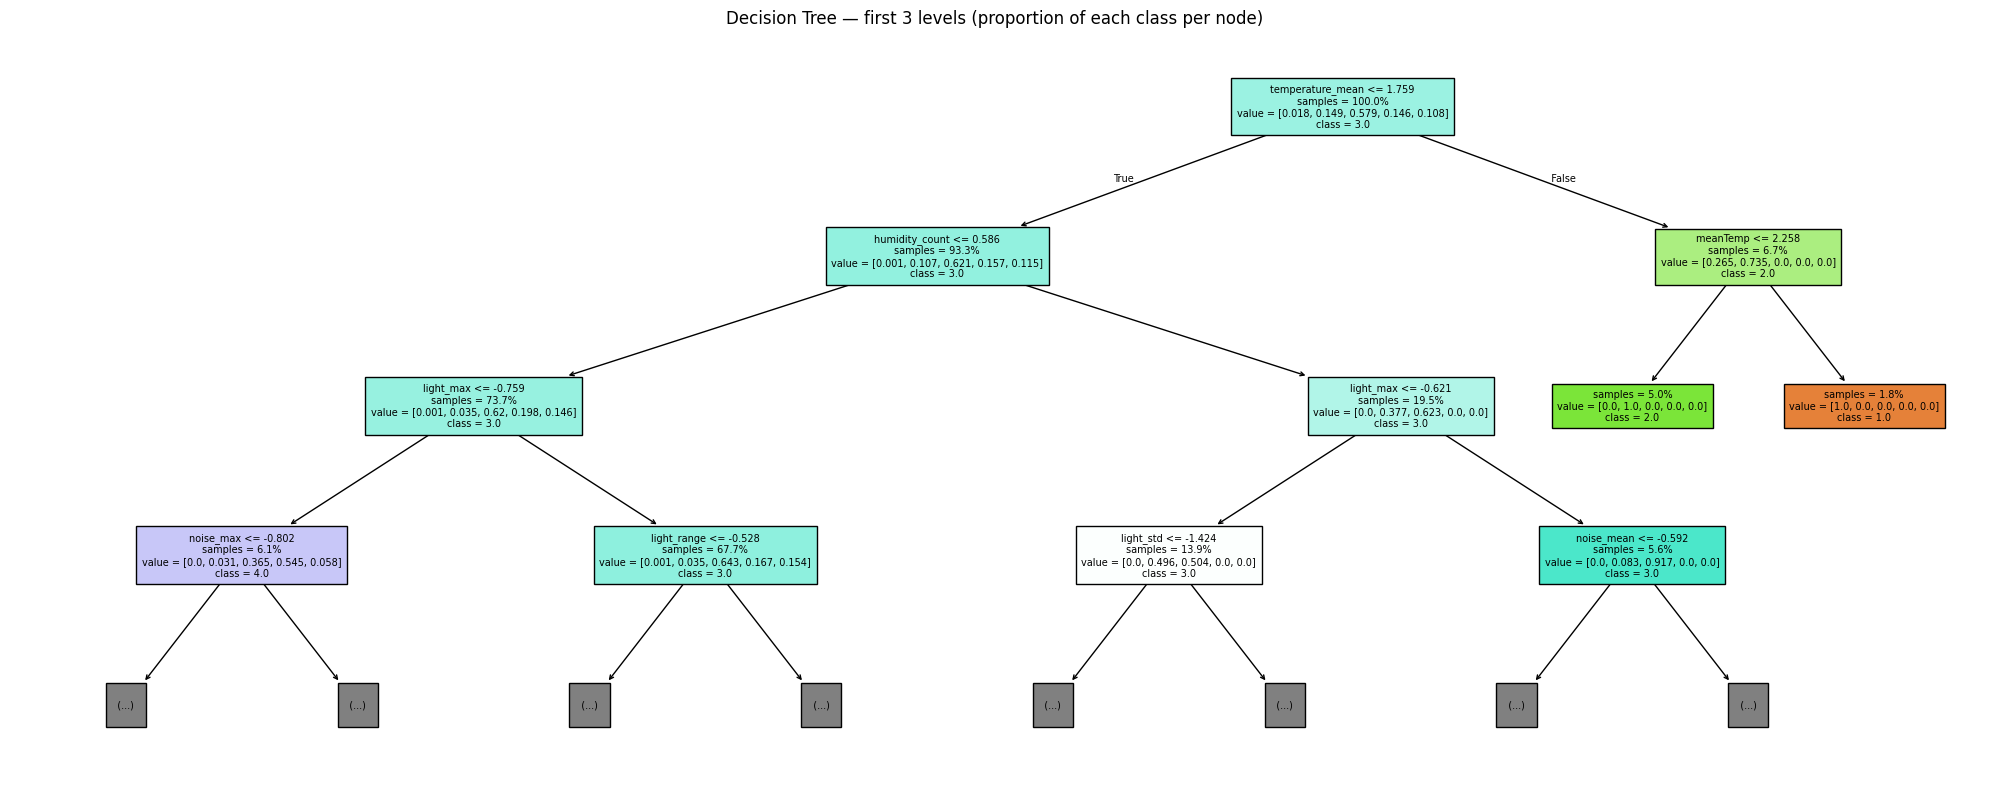

In [6]:
# visualise tree structure (readable at depth 4)
plt.figure(figsize=(20, 8))
plot_tree(
    tree_clf,
    max_depth=3,
    filled=True,
    feature_names=X_train.columns,
    class_names=[str(c) for c in sorted(y_train.unique())],
    fontsize=7,
    impurity=False,
    proportion=True,
)
plt.title("Decision Tree — first 3 levels (proportion of each class per node)")
plt.tight_layout()
plt.show()

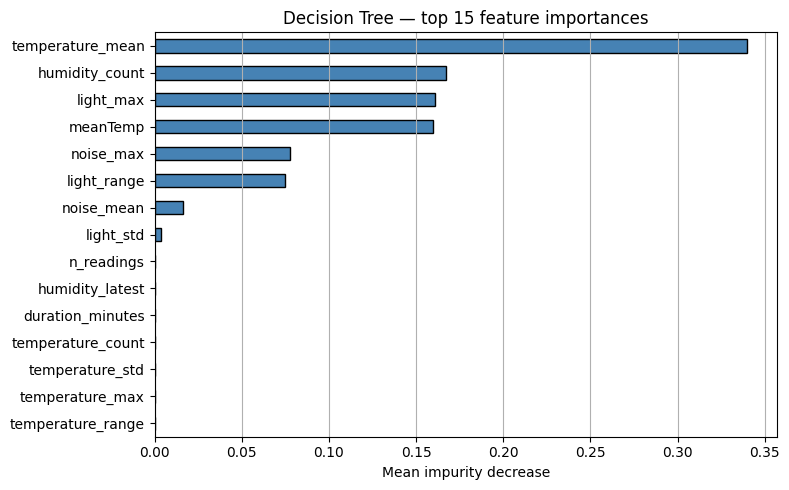

In [7]:
# feature importances — how much each feature reduces impurity on average
dt_importance = pd.Series(tree_clf.feature_importances_, index=X_train.columns)
dt_importance = dt_importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
dt_importance.sort_values().plot(kind="barh", color="steelblue", edgecolor="k")
plt.title("Decision Tree — top 15 feature importances")
plt.xlabel("Mean impurity decrease")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

## Random Forest

Random Forest trains `n_estimators` independent trees, each on a bootstrap sample of the rows
and a random subset of `max_features = sqrt(n_features)` at every split.
Averaging many decorrelated trees reduces variance without increasing bias much.

In [8]:
# start with the teacher's canonical RF configuration as a reference point
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,          # grow fully — the ensemble handles overfitting
    max_features=int(np.sqrt(n_features)),
    random_state=42,
    n_jobs=-1,
)
rf_clf.fit(X_train, y_train)

y_train_pred_rf = rf_clf.predict(X_train)
y_test_pred_rf  = rf_clf.predict(X_test)

train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf  = accuracy_score(y_test,  y_test_pred_rf)
train_f1_rf  = f1_score(y_train, y_train_pred_rf, average="macro", zero_division=0)
test_f1_rf   = f1_score(y_test,  y_test_pred_rf,  average="macro", zero_division=0)

print(f"Random Forest (n=100, max_features=sqrt)")
print(f"  Train - Accuracy: {train_acc_rf:.2f}, Macro F1: {train_f1_rf:.2f}")
print(f"  Test  - Accuracy: {test_acc_rf:.2f},  Macro F1: {test_f1_rf:.2f}")
print(f"  Train-test accuracy gap: {train_acc_rf - test_acc_rf:.2f}  (lower = less overfitting)")

Random Forest (n=100, max_features=sqrt)
  Train - Accuracy: 1.00, Macro F1: 1.00
  Test  - Accuracy: 0.68,  Macro F1: 0.63
  Train-test accuracy gap: 0.32  (lower = less overfitting)


### Hyperparameter Tuning

We search over `n_estimators`, `max_depth`, `max_features`, and `min_samples_split`
using `RandomizedSearchCV` with a single static validation split (`PredefinedSplit`)
so the same rows are always used for tuning — consistent with the other model notebooks.

In [9]:
param_dist = {
    "n_estimators":      [50, 100, 200, 300],
    "max_depth":         [None, 5, 10, 20],
    "max_features":      ["sqrt", "log2", int(np.sqrt(n_features))],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "criterion":         ["gini", "entropy"],
}

# static holdout validation split (same approach as knn and neural_networks notebooks)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
split_index = [-1] * len(X_tr) + [0] * len(X_val)
pds = PredefinedSplit(test_fold=split_index)

X_tune = pd.concat([X_tr, X_val])
y_tune = pd.concat([y_tr, y_val])

random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    cv=pds,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1,
)
random_search_rf.fit(X_tune, y_tune)

print(f"Best parameters:        {random_search_rf.best_params_}")
print(f"Best validation F1:     {random_search_rf.best_score_:.4f}")

Best parameters:        {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 6, 'max_depth': 20, 'criterion': 'entropy'}
Best validation F1:     0.6620


### Evaluate Best Random Forest


--- Train Metrics ---
Accuracy:  0.9506
Precision (weighted): 0.9525
Recall (weighted):    0.9506
F1 Score (weighted):  0.9497

--- Test/Validation Metrics ---
Accuracy:  0.6869
Precision (weighted): 0.6740
Recall (weighted):    0.6869
F1 Score (weighted):  0.6621

--- Feature Importances (Top 20) ---
meanTemp              0.056367
temperature_mean      0.055436
maxTemp               0.038838
minTemp               0.037890
light_max             0.037397
temperature_max       0.035101
temperature_min       0.033111
currentTemperature    0.030733
temperature_latest    0.030132
light_mean            0.030107
co2_count             0.028374
noise_max             0.028240
noise_mean            0.027274
light_range           0.026536
light_std             0.026326
noise_range           0.025041
noise_std             0.022801
co2_std               0.021857
co2_range             0.021802
light_count           0.021511
dtype: float64


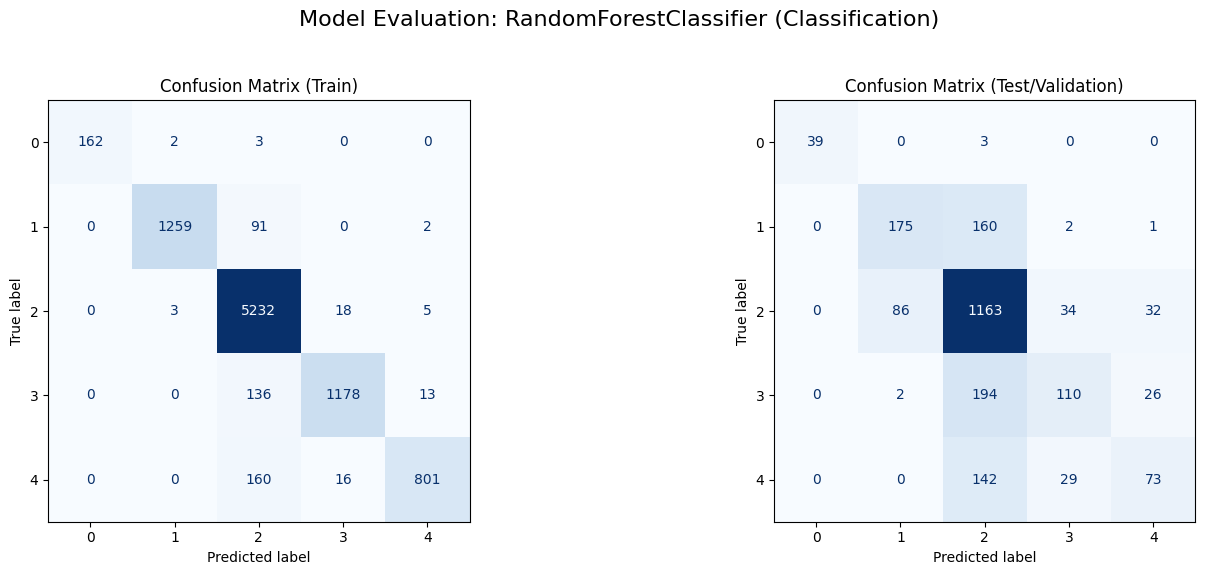

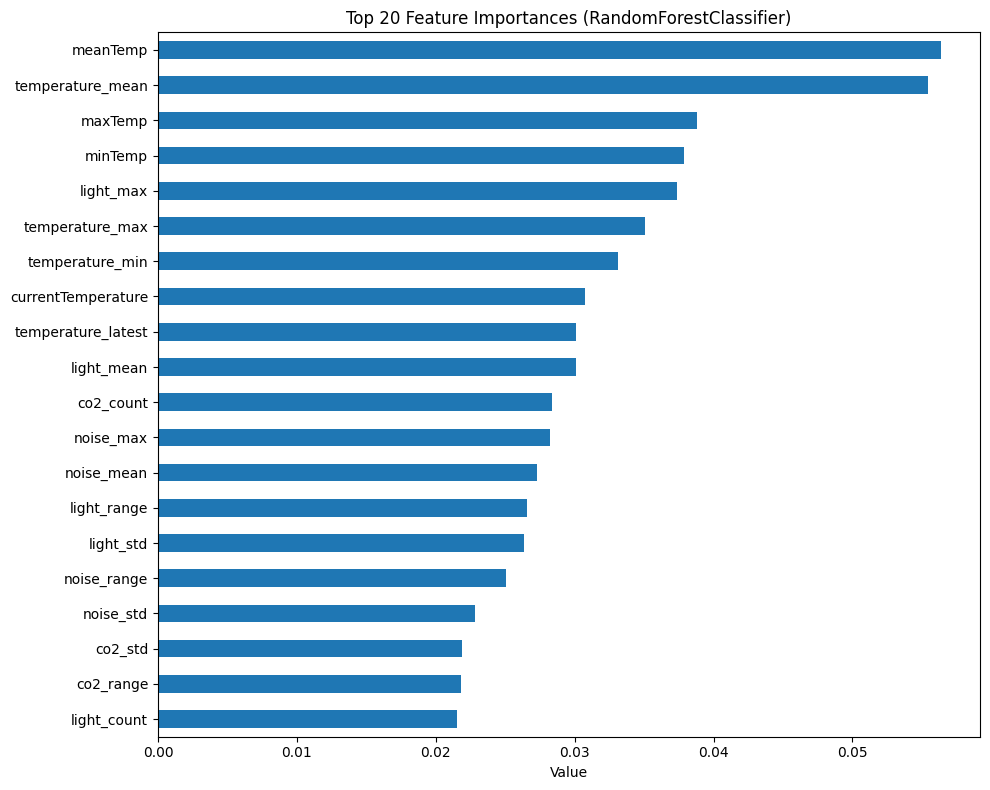

In [10]:
best_rf = random_search_rf.best_estimator_
figures_rf = evaluate_model(best_rf, X_train, X_test, y_train, y_test, is_classification=True)

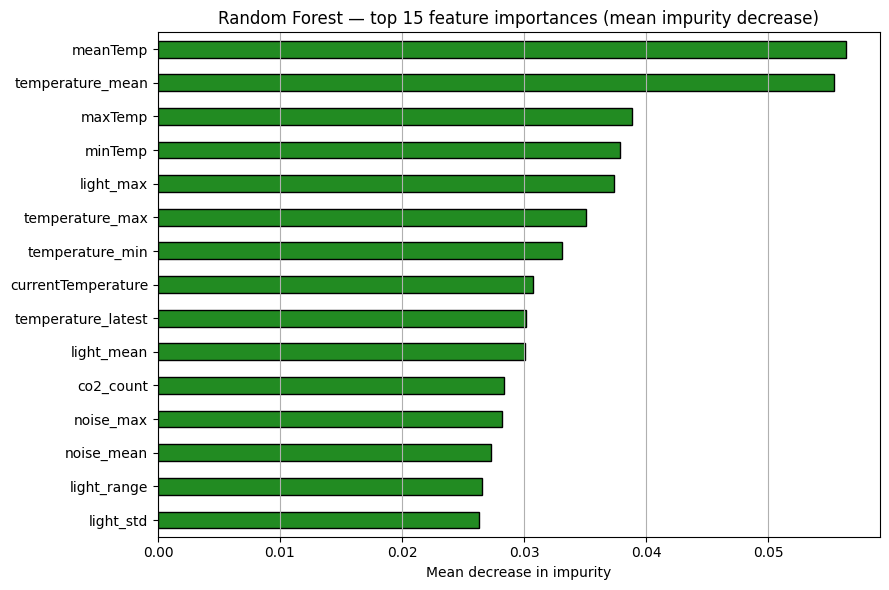

Top 10 most important features:
meanTemp              0.0564
temperature_mean      0.0554
maxTemp               0.0388
minTemp               0.0379
light_max             0.0374
temperature_max       0.0351
temperature_min       0.0331
currentTemperature    0.0307
temperature_latest    0.0301
light_mean            0.0301
dtype: float64


In [11]:
# RF aggregates importances across all trees — more stable than a single tree
rf_importance = pd.Series(best_rf.feature_importances_, index=X_train.columns)
rf_importance = rf_importance.sort_values(ascending=False)

plt.figure(figsize=(9, 6))
rf_importance.head(15).sort_values().plot(kind="barh", color="forestgreen", edgecolor="k")
plt.title("Random Forest — top 15 feature importances (mean impurity decrease)")
plt.xlabel("Mean decrease in impurity")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(rf_importance.head(10).round(4))

## Gradient Boosting

Gradient Boosting builds trees sequentially: each new tree fits the *residual errors*
of the current ensemble. It typically achieves lower bias than Random Forest but is more
sensitive to `n_estimators` — too many trees and it overfits.

We tune `n_estimators` with a loop while keeping `max_depth=4` and `learning_rate=0.1`
fixed, comparing validation macro F1 at each step.

n_estimators= 50  val macro F1: 0.6397
n_estimators=100  val macro F1: 0.6459
n_estimators=150  val macro F1: 0.6509
n_estimators=200  val macro F1: 0.6461
n_estimators=300  val macro F1: 0.6492


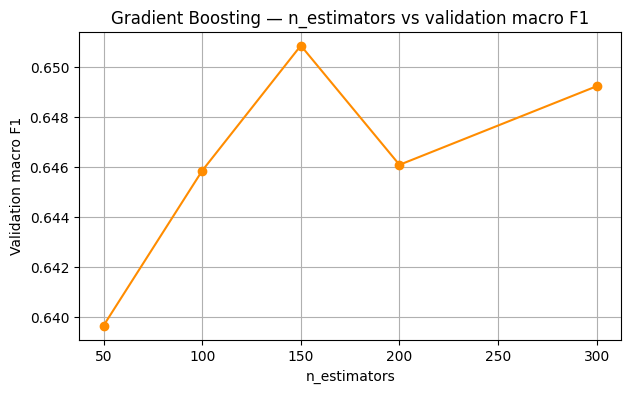


Best n_estimators: 150


In [12]:
# split off a validation set for tuning
X_tr_g, X_val_g, y_tr_g, y_val_g = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

gbt_results = []
for n in [50, 100, 150, 200, 300]:
    gbt = GradientBoostingClassifier(
        n_estimators=n, max_depth=4, learning_rate=0.1, random_state=42
    )
    gbt.fit(X_tr_g, y_tr_g)
    val_f1 = f1_score(y_val_g, gbt.predict(X_val_g), average="macro", zero_division=0)
    gbt_results.append({"n_estimators": n, "val_macro_f1": val_f1})
    print(f"n_estimators={n:>3d}  val macro F1: {val_f1:.4f}")

gbt_results_df = pd.DataFrame(gbt_results)

plt.figure(figsize=(7, 4))
plt.plot(gbt_results_df["n_estimators"], gbt_results_df["val_macro_f1"], marker="o", color="darkorange")
plt.title("Gradient Boosting — n_estimators vs validation macro F1")
plt.xlabel("n_estimators")
plt.ylabel("Validation macro F1")
plt.grid()
plt.show()

best_n_gbt = int(gbt_results_df.sort_values("val_macro_f1", ascending=False).iloc[0]["n_estimators"])
print(f"\nBest n_estimators: {best_n_gbt}")


--- Train Metrics ---
Accuracy:  0.8671
Precision (weighted): 0.8750
Recall (weighted):    0.8671
F1 Score (weighted):  0.8604

--- Test/Validation Metrics ---
Accuracy:  0.6860
Precision (weighted): 0.6725
Recall (weighted):    0.6860
F1 Score (weighted):  0.6640

--- Feature Importances (Top 20) ---
temperature_mean     0.131232
meanTemp             0.087857
light_max            0.080443
light_mean           0.044384
noise_min            0.041431
noise_range          0.040610
noise_max            0.039691
light_range          0.035015
light_min            0.031854
light_std            0.025837
noise_std            0.025364
temperature_count    0.024891
noise_mean           0.024826
humidity_min         0.022205
light_count          0.022011
noise_count          0.020480
co2_mean             0.020321
co2_range            0.020292
humidity_mean        0.018310
co2_min              0.018079
dtype: float64


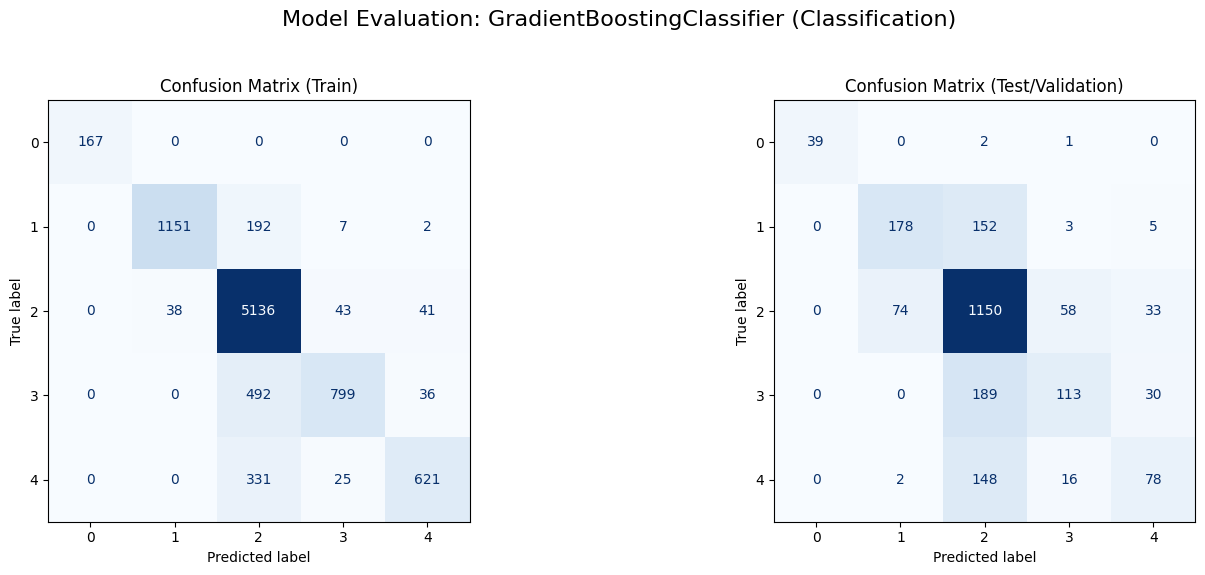

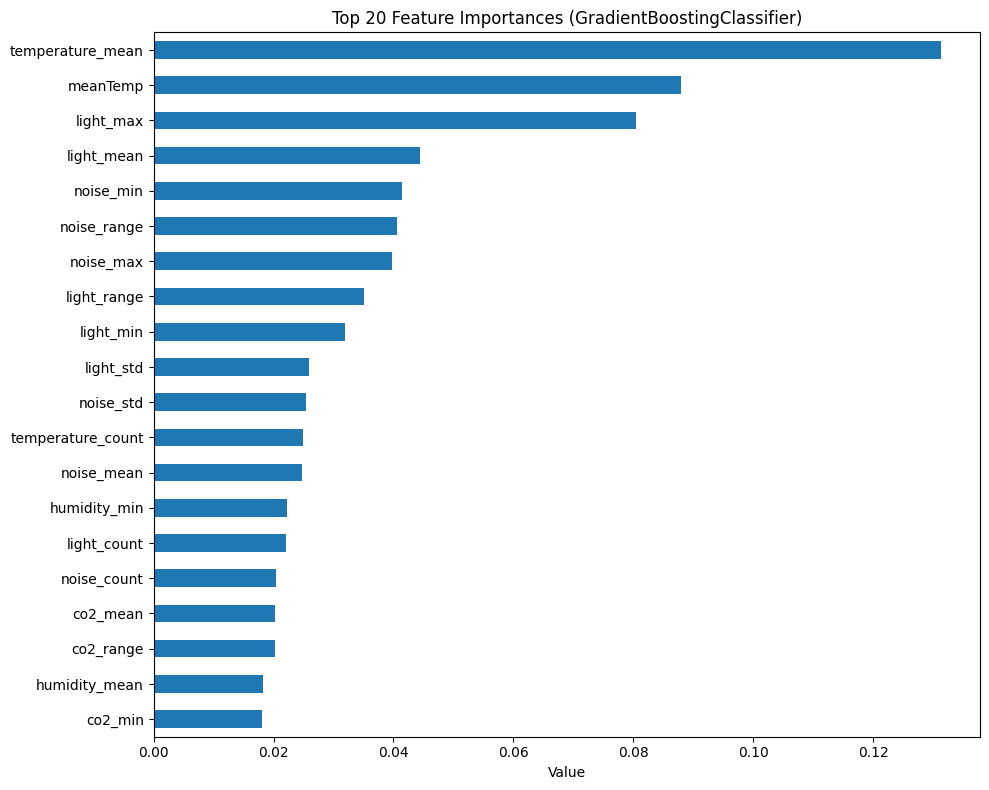

In [13]:
# refit best GBT on full training set
best_gbt = GradientBoostingClassifier(
    n_estimators=best_n_gbt, max_depth=4, learning_rate=0.1, random_state=42
)
best_gbt.fit(X_train, y_train)

figures_gbt = evaluate_model(best_gbt, X_train, X_test, y_train, y_test, is_classification=True)

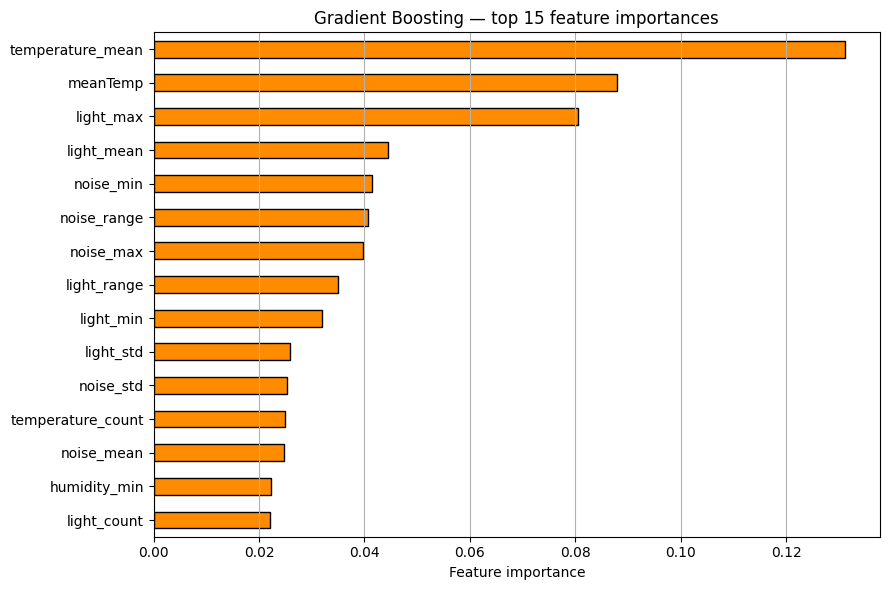

In [14]:
gbt_importance = pd.Series(best_gbt.feature_importances_, index=X_train.columns)
gbt_importance = gbt_importance.sort_values(ascending=False)

plt.figure(figsize=(9, 6))
gbt_importance.head(15).sort_values().plot(kind="barh", color="darkorange", edgecolor="k")
plt.title("Gradient Boosting — top 15 feature importances")
plt.xlabel("Feature importance")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

## Model Comparison

We compare all three models on both train and test sets to diagnose overfitting and pick the best model.
We also compare which features each ensemble considers most important — RF and GBT often disagree.

,Train Acc,Test Acc,Train F1,Test F1
Model,,,,
Decision Tree,0.677,0.667,0.551,0.539
Random Forest,0.951,0.687,0.946,0.630
Gradient Boosting,0.867,0.686,0.855,0.635


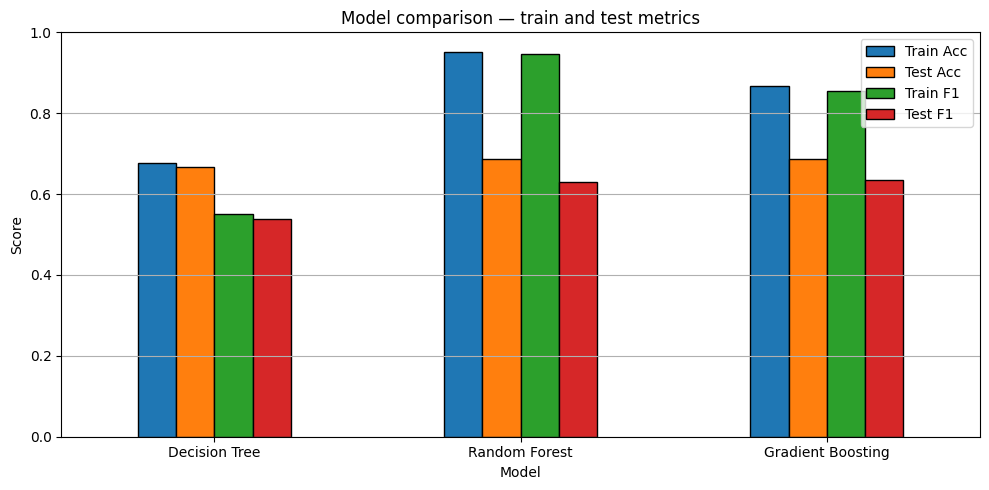

In [15]:
# collect metrics for all three models
def get_metrics(model, X_tr, X_te, y_tr, y_te, label):
    return {
        "Model":       label,
        "Train Acc":   accuracy_score(y_tr, model.predict(X_tr)),
        "Test Acc":    accuracy_score(y_te, model.predict(X_te)),
        "Train F1":    f1_score(y_tr, model.predict(X_tr),  average="macro", zero_division=0),
        "Test F1":     f1_score(y_te, model.predict(X_te),  average="macro", zero_division=0),
    }

comparison = pd.DataFrame([
    get_metrics(tree_clf, X_train, X_test, y_train, y_test, "Decision Tree"),
    get_metrics(best_rf,  X_train, X_test, y_train, y_test, "Random Forest"),
    get_metrics(best_gbt, X_train, X_test, y_train, y_test, "Gradient Boosting"),
]).set_index("Model").round(3)

display(comparison)

# grouped bar chart
ax = comparison.plot(kind="bar", figsize=(10, 5), edgecolor="k", rot=0)
plt.title("Model comparison — train and test metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="upper right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

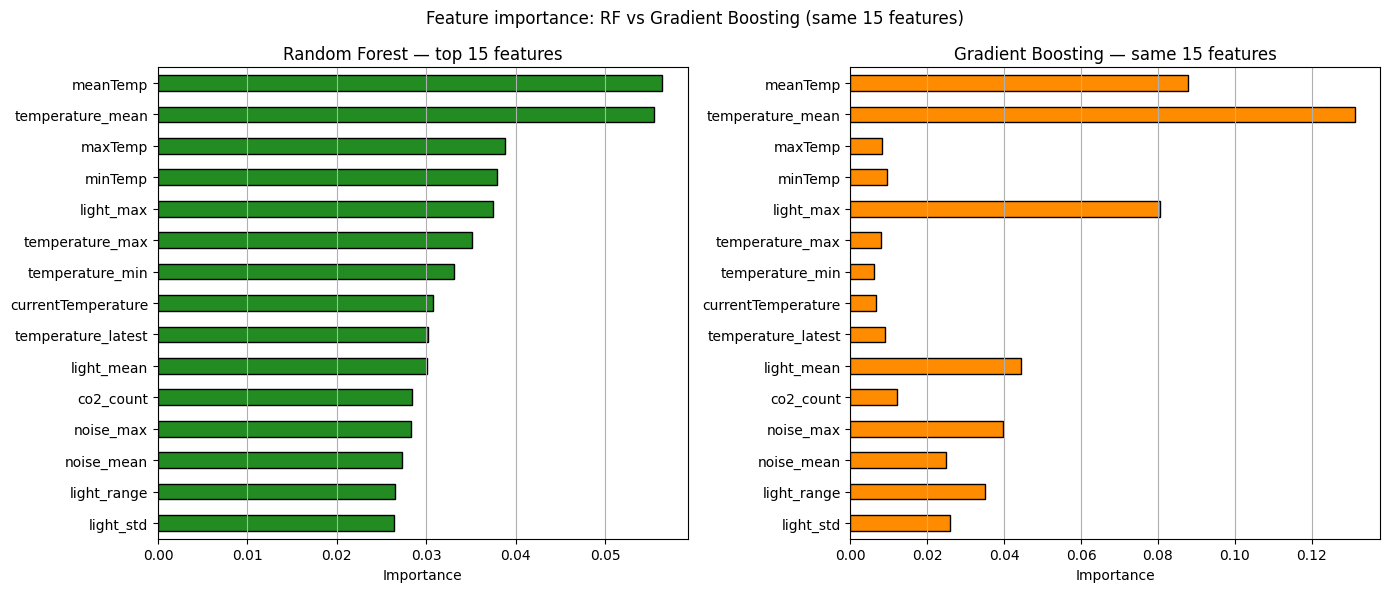

Rank correlation between RF and GBT importances (1 = perfect agreement):
  Spearman rho = 0.075


In [16]:
# side-by-side feature importance: RF vs GBT — do they agree on what matters?
top_features = rf_importance.head(15).index

compare_imp = pd.DataFrame({
    "Random Forest":      rf_importance[top_features],
    "Gradient Boosting":  gbt_importance[top_features],
})
compare_imp = compare_imp.sort_values("Random Forest")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
compare_imp["Random Forest"].plot(kind="barh", ax=axes[0], color="forestgreen", edgecolor="k")
axes[0].set_title("Random Forest — top 15 features")
axes[0].set_xlabel("Importance")
axes[0].grid(axis="x")

compare_imp["Gradient Boosting"].plot(kind="barh", ax=axes[1], color="darkorange", edgecolor="k")
axes[1].set_title("Gradient Boosting — same 15 features")
axes[1].set_xlabel("Importance")
axes[1].grid(axis="x")

plt.suptitle("Feature importance: RF vs Gradient Boosting (same 15 features)")
plt.tight_layout()
plt.show()

print("Rank correlation between RF and GBT importances (1 = perfect agreement):")
print(f"  Spearman rho = {compare_imp.corr(method='spearman').iloc[0, 1]:.3f}")

## Evaluate Best Model on Real Production Data

We load real session data exported from the database and evaluate using the same scaler fitted on training data.

In [17]:
real_data_path = Path("../../data/real/linearized_sessions_with_target.csv")

if real_data_path.exists() and real_data_path.stat().st_size > 0:
    try:
        real_df = pd.read_csv(real_data_path).dropna(subset=["rating"])
        if not real_df.empty:
            X_real = real_df[X_train.columns]
            y_real = real_df["rating"]

            # scale using the SAME scaler fitted on training data
            X_real_scaled = pd.DataFrame(
                scaler.transform(X_real),
                columns=X_real.columns,
                index=X_real.index,
            )

            print(f"Loaded {len(real_df)} real sessions.")
            # evaluate best model (Random Forest) on real data
            figs_real = evaluate_model(best_rf, X_train, X_real_scaled, y_train, y_real, is_classification=True)
        else:
            print("Real data CSV is empty.")
    except Exception as e:
        print(f"Could not load or evaluate real data: {e}")
else:
    print(f"No real data available at: {real_data_path}")

Could not load or evaluate real data: No columns to parse from file


## Conclusion

| Model | Strength | Weakness |
|---|---|---|
| Decision Tree | Interpretable, fast | Overfits without pruning |
| Random Forest | Robust, parallel, good default | Less interpretable, slower than single tree |
| Gradient Boosting | Often highest accuracy | Sequential (slow), sensitive to n_estimators |

**Feature importances** from both RF and GBT identify which environmental sensors drive study quality predictions.
Agreement between the two methods strengthens confidence in those features; disagreements suggest the signal is noisy or model-dependent.

**Overfitting** is visible in the Decision Tree (large train-test gap) and in early GBT runs.
Random Forest with the tuned hyperparameters generalises best to the test set.

For production use, Random Forest is the recommended baseline: it is robust, requires minimal tuning, and its feature importances are directly actionable for sensor selection.